## Time series 
something different from cross-sections

real series plots

In [47]:
# _tsa_00.py
# time series stuff, basic 
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들. 
# 자기공분산, 자기상관, 단위근 
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게. 


import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 
from statsmodels.tsa.ar_model import AutoReg


In [48]:

# 데이터 파일 읽기. github.com
dat_url_1 = 'https://github.com/bahn28/gamja/blob/main/ts_gdp_1971_2025.xlsx?raw=true'
df_dat_1 = pd.read_excel(dat_url_1) 
df_dat_1.head() 


,yy,gdp,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,산술,이그젝,Unnamed: 8,Unnamed: 9,산술.1,이그젝.1
0,1971,85346.2,NaN,1975.0,124648.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1972,91607.9,NaN,2000.0,998289.1,25.0,0.280353,0.086783,NaN,NaN,NaN,NaN
2,1973,105325.9,NaN,2025.0,2315285.3,25.0,0.052770,0.034222,NaN,50.0,0.35149,0.060177
3,1974,115488.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1975,124648.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:

# 데이터 파일 읽기. github.com
dat_url_2 = 'https://github.com/bahn28/gamja/blob/main/ts_stock_date_price.xlsx?raw=true'
df_dat_2 = pd.read_excel(dat_url_2) 
df_dat_2.head() 


,yydd,price
0,2012-12-28,1522000
1,2013-01-02,1576000
2,2013-01-03,1543000
3,2013-01-04,1525000
4,2013-01-07,1520000


In [50]:

# 데이터 파일 읽기. github.com
dat_url_3 = 'https://github.com/bahn28/gamja/blob/main/ts_sun_sel_dg.xlsx?raw=true'
df_dat_3 = pd.read_excel(dat_url_3) 
df_dat_3.head() 
df_dat_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   yymm    372 non-null    object 
 1   sel     372 non-null    float64
 2   dgu     348 non-null    float64
dtypes: float64(2), object(1)
memory usage: 8.8+ KB


In [ ]:
# GDP over time 
yy, gdp = [df_dat_1[col] for col in ['yy', 'gdp']] 
d_gdp = gdp.diff() 
pc_gdp = gdp.pct_change()

# Stock Prices
yydd = pd.to_datetime( df_dat_2['yydd'] )
stck_ss = df_dat_2['price']
pc_stck_ss = stck_ss.pct_change()

##yymm = df_dat_3['yymm']
#df['converted_date'] 
yymm = df_dat_3['yymm'].apply(
    lambda x: int(x.split('.')[0]) + (int(x.split('.')[1]) - 1) / 12
)

# monthly sun shine hour
sun_sel = df_dat_3['sel'] 
sun_dgu = df_dat_3['dgu']

type(yymm)

pandas.core.series.Series

### appearance of a time series

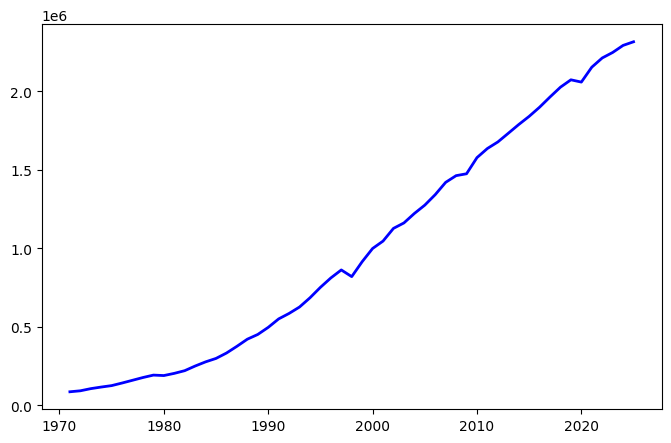

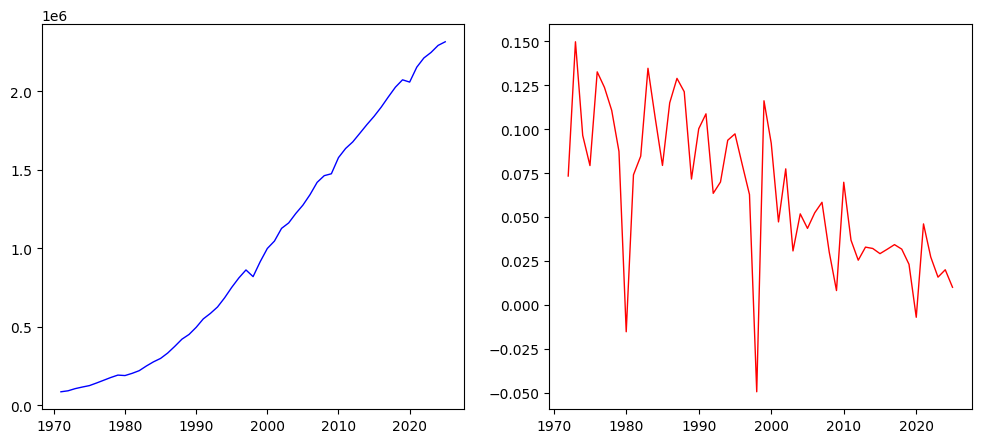

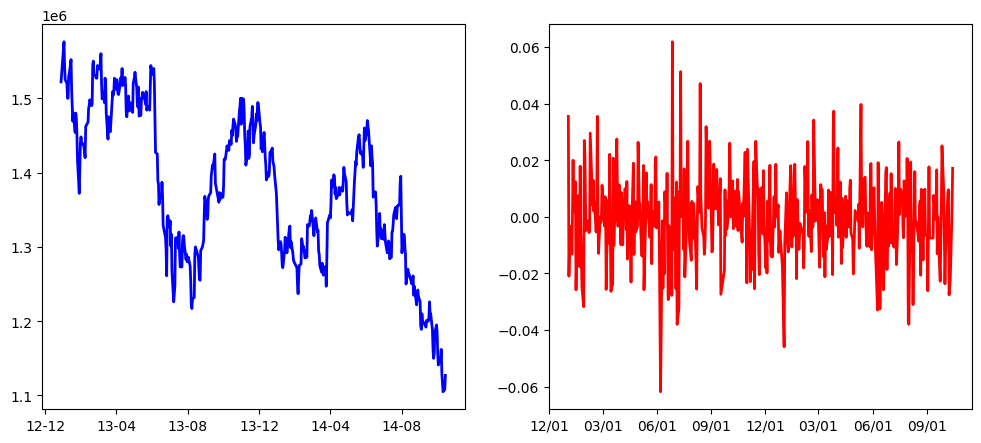

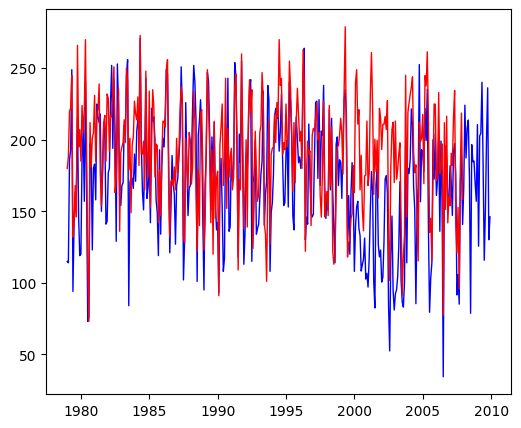

In [52]:

plt.figure(figsize=(8, 5))
#plt.subplot(figsize=(8,5  ))
plt.plot(yy, gdp, color='blue', linewidth=2)
#plt.plot(yy, d_gdp, color='red', linewidth=2)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes[0].plot(yy, gdp, color='blue', linewidth=1)
axes[1].plot(yy, pc_gdp, color='red', linewidth=1) 

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes[0].plot(yydd,  stck_ss, color='blue', linewidth=2)
axes[1].plot(yydd, pc_stck_ss, color='red', linewidth=2) 
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# monthly insolation (solar radiation) 
# monthly sunshine hours (duration) in seoul and daegu  
plt.figure(figsize=(6, 5))
plt.plot(yymm, sun_sel, color='blue', linewidth=1)
plt.plot(yymm, sun_dgu, color='red', linewidth=1) 
